In [1]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from scipy.linalg import eigh

# H4分子
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 1.2;; H 0 0 2.4;; H 0 0 3.6;",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)
problem = driver.run()
hamiltonian = problem.hamiltonian
# 获得二次量子化后的分子哈密顿量
second_q_op = hamiltonian.second_q_op()
mapper = JordanWignerMapper()


# 映射为量子比特哈密顿量
qubit_op_ham = mapper.map(second_q_op)
# 计算哈密顿量的本征值和本征向量
ham_matrix = qubit_op_ham.to_matrix()
eigenvalues, eigenvectors = eigh(ham_matrix)
# 获得基态的本征值和本征向量
exact_energy = eigenvalues[0]
exact_state = eigenvectors[:, 0]

将精确基态波函数 用 4个量子比特组成的基态表示出来 并画成柱状图

In [2]:
from jax._src import state
from qiskit.quantum_info import Statevector,state_fidelity
exact_state_vector = Statevector(exact_state)
print(exact_energy)

-4.013526187055421


In [12]:
from netket.hilbert import SpinOrbitalFermions

hibert_space_H4 = SpinOrbitalFermions(n_orbitals=4,s=1/2,n_fermions_per_spin=(2,2))

In [35]:
import numpy as np
hibert_space_H4.all_states()[0] # jaxlib._jax.ArrayImpl

type(np.asarray(hibert_space_H4.all_states())) # 转换为 ndarray

numpy.ndarray

In [39]:
arr = np.asarray(hibert_space_H4.all_states()[0])
"".join(arr.astype(str))

'00110011'

In [40]:
possible_states = [Statevector.from_label("".join(i.astype(str))) for i in np.asarray(hibert_space_H4.all_states()) ]
fidilities = [state_fidelity(exact_state_vector, each) for each in possible_states]

In [47]:
sum(fidilities)

0.9999999999999996

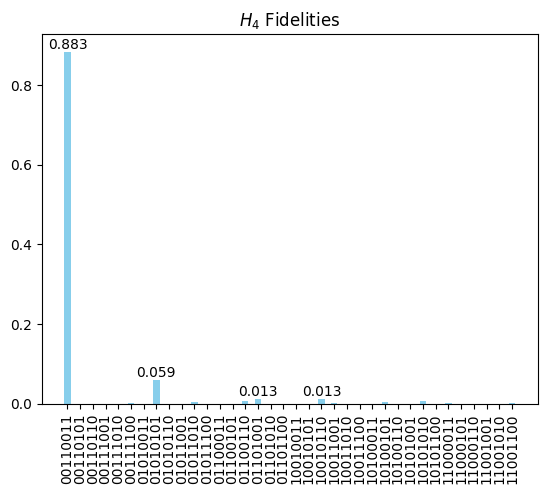

In [46]:
import matplotlib.pyplot as plt
fidilitiescategories = ["".join(i.astype(str)) for i in np.asarray(hibert_space_H4.all_states())]
values = fidilities
plt.title("$H_4$ Fidelities ")
# 创建条形图，通过 width 参数拉宽不同 bar 的间距
plt.bar(fidilitiescategories, values, color='skyblue', width=0.5)
# 设置横坐标标签竖向排列
plt.xticks(rotation='vertical')
# 在每个条形图上方标注数值，数值为 0 时不标出，数值精确到后三位
for i in range(len(fidilitiescategories)):
    if values[i] >= 0.01:
        plt.text(i, values[i], f'{values[i]:.3f}', ha='center', va='bottom')
